# 01 — Exploratory Data Analysis
**EM 630 · Electricity Demand Forecasting · Phase 2**

**Goal of this notebook.** Before fitting any model we want to know *what structure is in the data*, so that every feature and every model choice later on has a reason. EDA also tells us what results to *expect*, so the results in Phases 4–7 can be explained rather than just reported.

**How each section is organised**

| Step | What you'll see |
|---|---|
| ❓ Question | The one thing the figure answers |
| 💡 Why it matters | The link to forecasting / course concept |
| 🧮 Analysis code | The computation that produces the evidence (plotting code lives in `src/eda.py`) |
| 📊 Figure | Saved to `results/figures/` |
| ✅ Finding → 🔧 Decision | What we learned and what we do about it |

**A rule we follow:** any statistic that *drives a modelling decision* (autocorrelation, correlations, adjusted effects) is computed on the **training period only**. If we chose features by looking at the test period, our test score would be optimistic (a mild form of data leakage). Purely descriptive time plots use the whole series, with the split shaded.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))      # repo root
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from IPython.display import Image, display

from src import config, eda, features
pd.set_option("display.precision", 3)

def show(fig_name, width=900):
    display(Image(filename=str(config.FIG_DIR / f"{fig_name}.png"), width=width))

ctx = eda.load_context()          # raw -> clean hourly grid -> features -> chronological split (Phase 1)
obs, train_obs, sp = ctx.obs, ctx.train_obs, ctx.sp
print(f"Observed hours : {len(obs):,}   ({obs.index.min():%d %b %Y} → {obs.index.max():%d %b %Y})")
sp.summary()

Observed hours : 23,977   (01 Apr 2023 → 12 Jan 2026)


,split,rows,start,end,mean_mw
0,train,16666,2023-04-08 00:00:00,2025-03-18 09:00:00,4326.689
1,val,2381,2025-03-18 10:00:00,2025-06-26 08:00:00,4931.962
2,test,4762,2025-06-26 09:00:00,2026-01-12 23:00:00,4563.450


`obs` = hours that were actually recorded (no imputed values). `train_obs` = the observed hours inside the training period, which we use for decision-driving statistics.

---
## 1. Data quality

### Fig 10 — How complete is the data?
❓ *How many hours are missing, and in what pattern?*
💡 Lag features like "load 24 hours ago" only make sense on a **complete hourly grid**. A gap that silently shifts rows would make `shift(24)` point at the wrong hour.

In [2]:
from src import data
gaps = data.gap_report(ctx.hourly)                       # one row per run of missing hours
print(f"Missing hours: {ctx.hourly['is_missing_raw'].sum()}  in {len(gaps)} gaps")
print(gaps['hours'].describe()[['mean', '50%', 'max']].round(1).to_string())
print(f"Gaps ≤ 3 h: {(gaps.hours <= 3).sum()},  longer: {(gaps.hours > 3).sum()}")
gaps.sort_values('hours', ascending=False).head(5)

Missing hours: 455  in 241 gaps
mean     1.9
50%      1.0
max     49.0
Gaps ≤ 3 h: 223,  longer: 18


,start,hours
36,2023-12-31 23:00:00,49
240,2026-01-07 16:00:00,32
116,2024-06-13 10:00:00,14
201,2024-12-29 11:00:00,13
12,2023-07-20 12:00:00,12


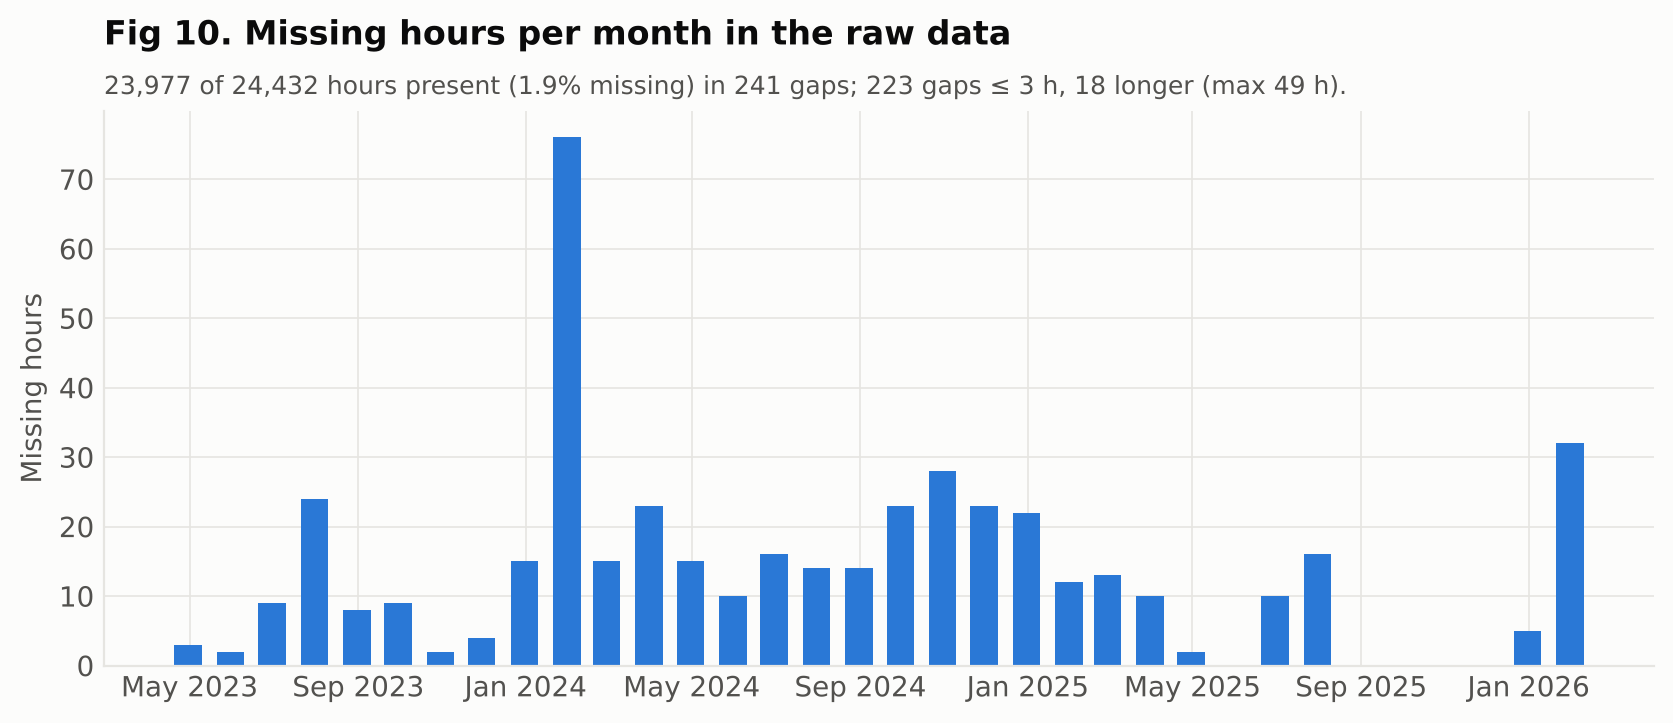

In [3]:
f10 = eda.f10_missing_hours(ctx); show("F10_missing_hours")

✅ **Finding.** About 1.9% of hours are missing, mostly isolated single hours; 18 gaps are longer (max 49 h around New Year 2024).
🔧 **Decision (implemented in Phase 1).** Short gaps (≤ 3 h): forward-fill, which is *causal* (it uses only the past). Long gaps: fill with the same hour last week, used **only as history for lag features**. An imputed hour is **never** used as a target to score, so our error metrics are computed on real measurements only.

### Fig 11 — Are there outliers to remove?
❓ *Are extreme values errors we should delete?*
💡 The original project plan said "3σ outlier removal". Before deleting anything we check *what* the extreme values are.

In [4]:
mu, sd = train_obs["load_mw"].mean(), train_obs["load_mw"].std()       # train statistics only
out = obs[(obs["load_mw"] - mu).abs() > 3 * sd]
print(f"μ = {mu:,.0f} MW, σ = {sd:,.0f} MW  →  {len(out)} hours beyond ±3σ")
out[["load_mw"]].assign(date=out.index.date, hour=out.index.hour)

μ = 4,313 MW, σ = 1,340 MW  →  11 hours beyond ±3σ


,load_mw,date,hour
timestamp,,,
2024-06-18 14:00:00,8518.75,2024-06-18,14
2024-06-18 15:00:00,8610.85,2024-06-18,15
2024-06-18 16:00:00,8424.01,2024-06-18,16
2024-06-19 14:00:00,8549.17,2024-06-19,14
2024-06-19 15:00:00,8631.53,2024-06-19,15
2024-06-19 16:00:00,8529.03,2024-06-19,16
2025-06-12 15:00:00,8387.63,2025-06-12,15
2025-06-12 22:00:00,8360.50,2025-06-12,22
2025-06-12 23:00:00,8419.34,2025-06-12,23


In [5]:
# What is the small hump near 1,900 MW in the histogram?
low = obs[(obs.load_mw > 1700) & (obs.load_mw < 2100)]
print("months:", low.index.month.value_counts().sort_index().to_dict())
print("hours :", low.index.hour.value_counts().sort_index().to_dict())

months: {1: 211, 2: 210, 3: 125, 4: 8, 11: 209, 12: 320}
hours : {0: 48, 1: 228, 2: 276, 3: 243, 4: 281, 5: 7}


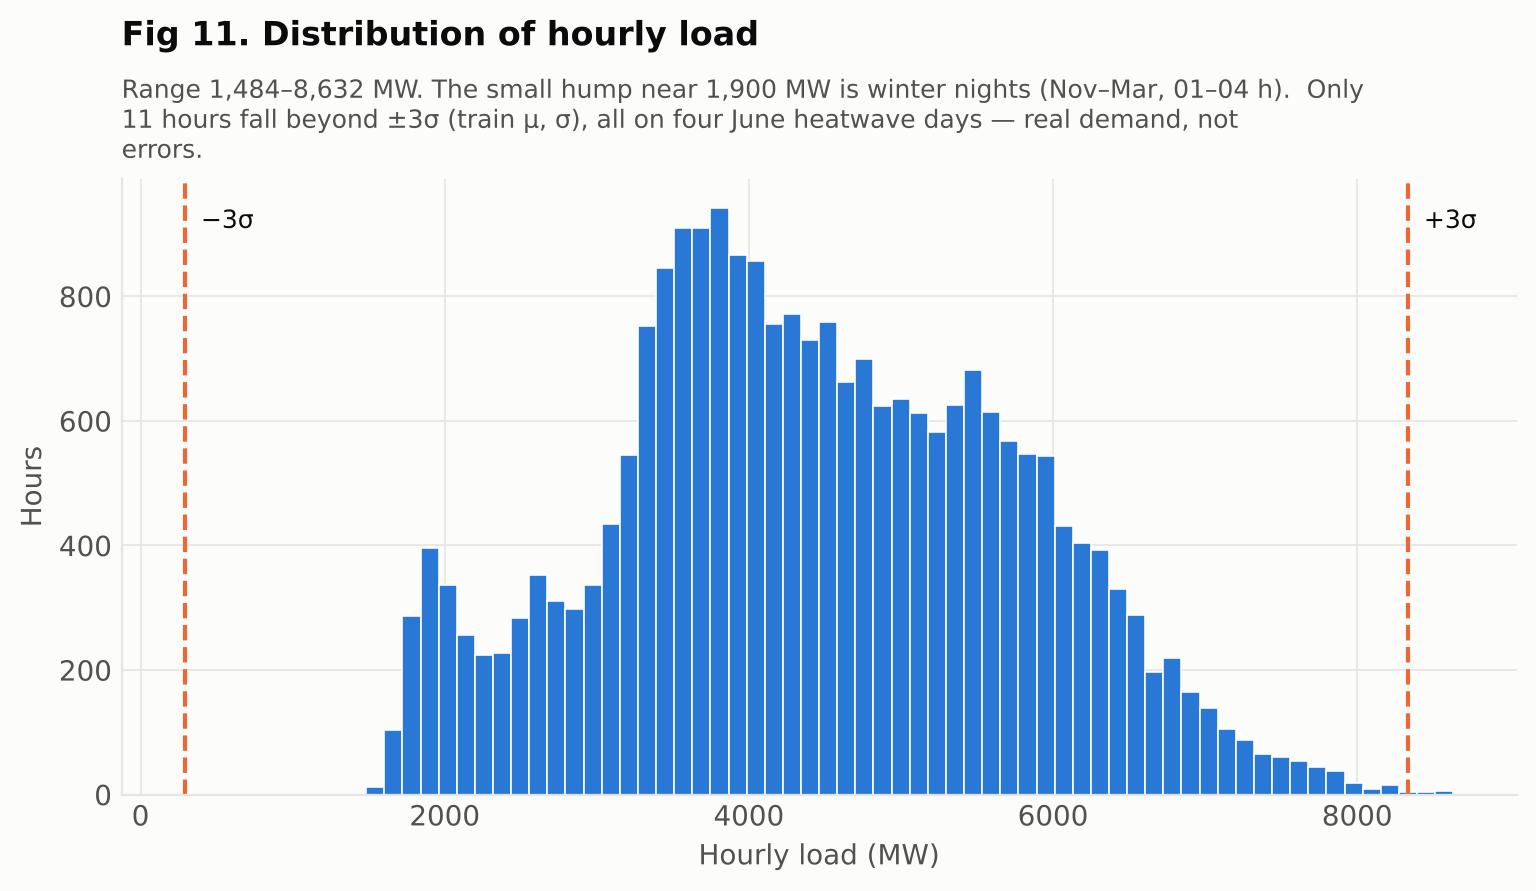

In [6]:
f11 = eda.f11_load_distribution(ctx); show("F11_load_distribution")

✅ **Finding.** All 11 "outliers" are above +3σ and fall on four June heatwave days: they are **real demand**, not errors. The second hump near 1,900 MW is winter nights (Nov–Mar, 01–04 h), a distinct low-load regime.
🔧 **Decision. We do not delete outliers.** (1) Deleting rows punches holes in the hourly grid and breaks the lag features. (2) Peaks are the hours a utility most needs forecast correctly; removing them would make the model look better on paper and worse in practice. Peak accuracy gets its own analysis in Phase 7.

---
## 2. Temporal structure

### Fig 1 — How does load evolve, and where do the splits fall?
❓ *Trend? Seasonality? Is the test period representative?*
💡 A chronological split means the model is trained on the past and judged on the future. We need to know whether the future looks different (distribution shift).

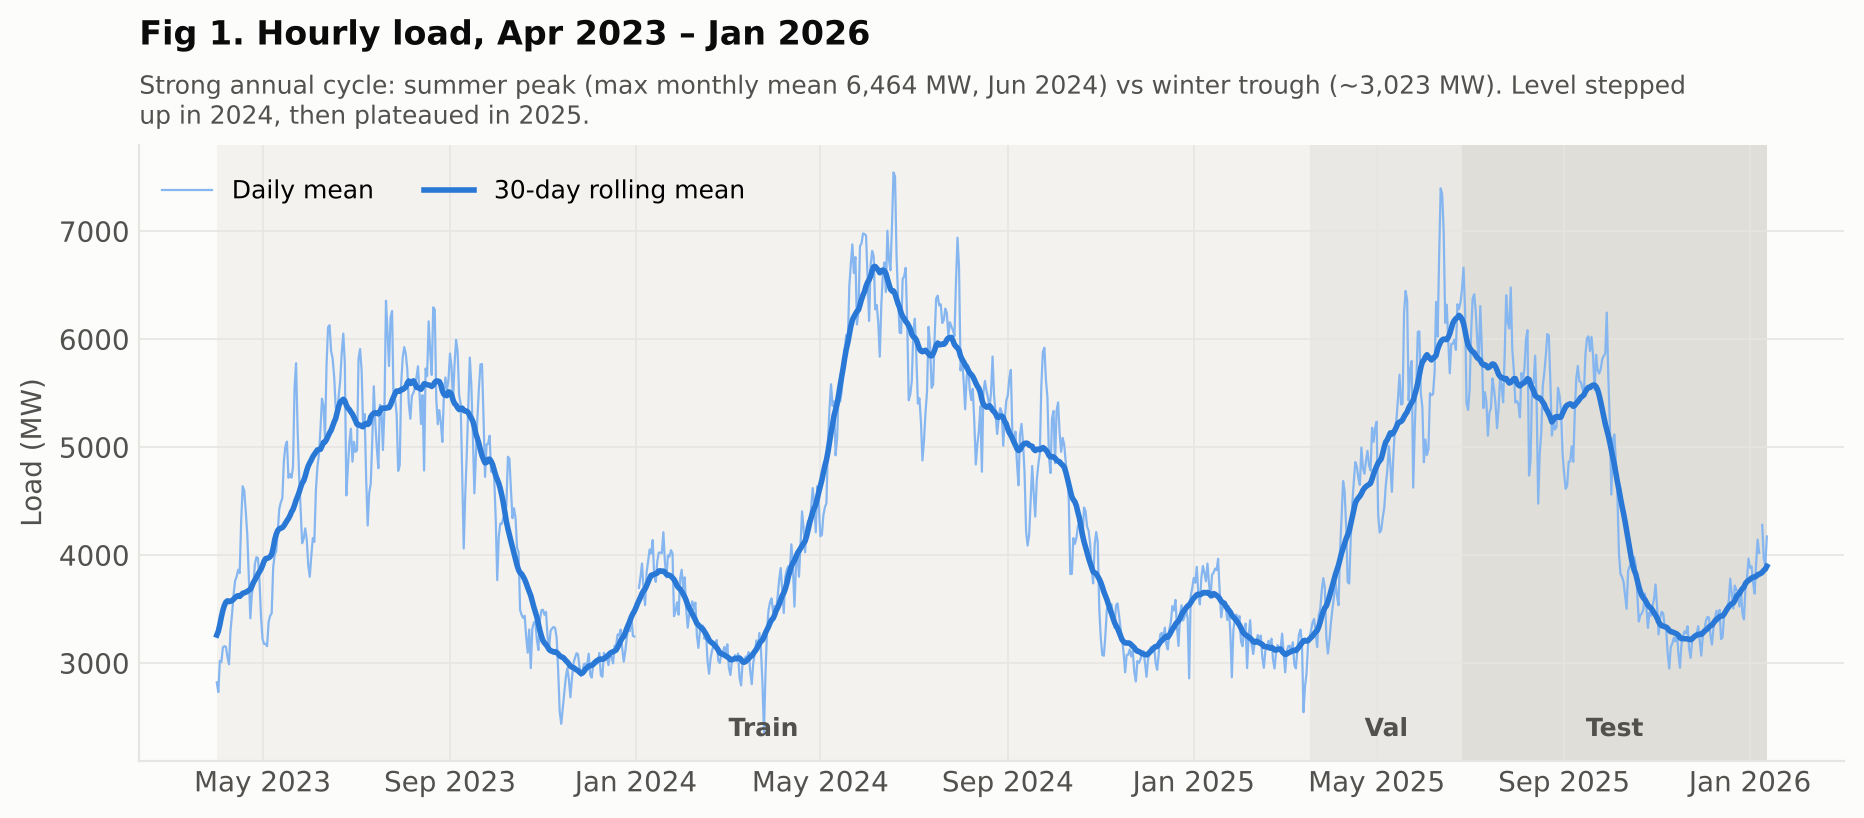

,split,start,end,mean_mw
0,train,2023-04-08 00:00:00,2025-03-18 09:00:00,4326.689
1,val,2025-03-18 10:00:00,2025-06-26 08:00:00,4931.962
2,test,2025-06-26 09:00:00,2026-01-12 23:00:00,4563.450


In [7]:
f01 = eda.f01_timeline(ctx); show("F01_timeline_with_split", 1000)
sp.summary()[["split", "start", "end", "mean_mw"]]

✅ **Finding.** The annual cycle dominates (summer peak, winter trough). Val (Mar–Jun 2025) is in the hot season, which is why its mean is higher than Train's. Test (Jun 2025 – Jan 2026) covers monsoon, post-monsoon and winter, so it is a demanding test.

### Fig 4 — Is there a growth trend the models must extrapolate?
💡 Tree-based models (Phase 5) **cannot predict outside the range they saw in training**. If demand were growing steadily, the test period would sit above the training range and trees would systematically under-forecast.

In [8]:
mm = obs.groupby([obs.index.year, obs.index.month])["load_mw"].mean().unstack(0)   # month x year
for a, b in [(2023, 2024), (2024, 2025)]:
    both = mm[[a, b]].dropna()
    print(f"{b} vs {a} (same months): {((both[b] / both[a]) - 1).mean() * 100:+.1f}%")

2024 vs 2023 (same months): +11.2%
2025 vs 2024 (same months): -0.7%


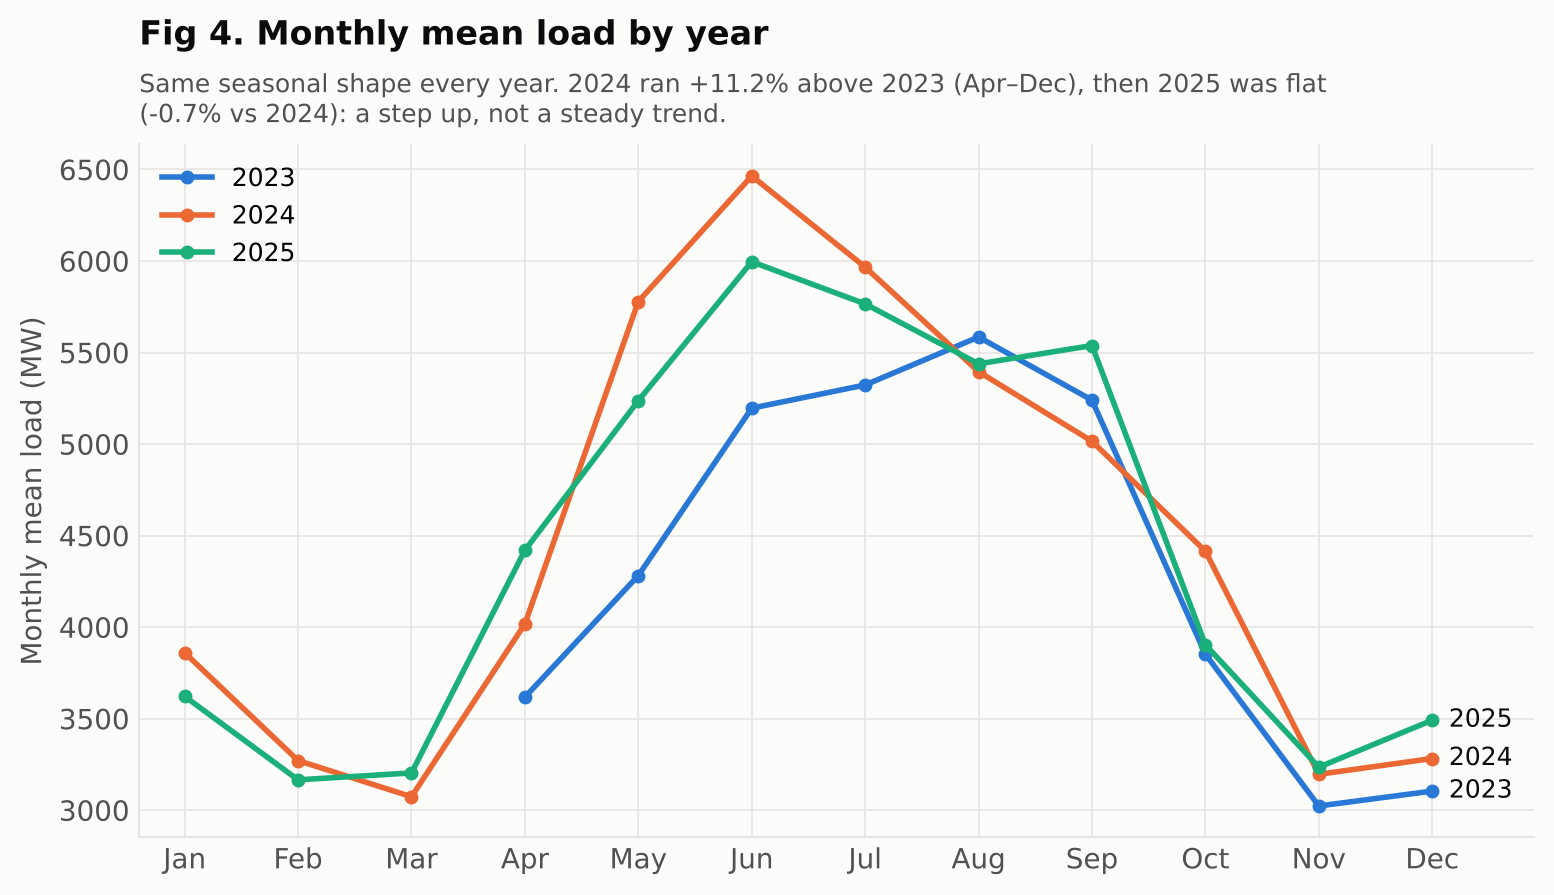

In [9]:
f04 = eda.f04_year_on_year(ctx); show("F04_year_on_year")

✅ **Finding.** Load **stepped up** about 11% in 2024, then **plateaued** in 2025: a level shift, not a steady trend.
🔧 **Decision.** No de-trending step. The higher 2024 level is already inside Train, and the lag / rolling-mean features carry the *recent* level into every forecast.

### Fig 2 — What does a typical day look like?

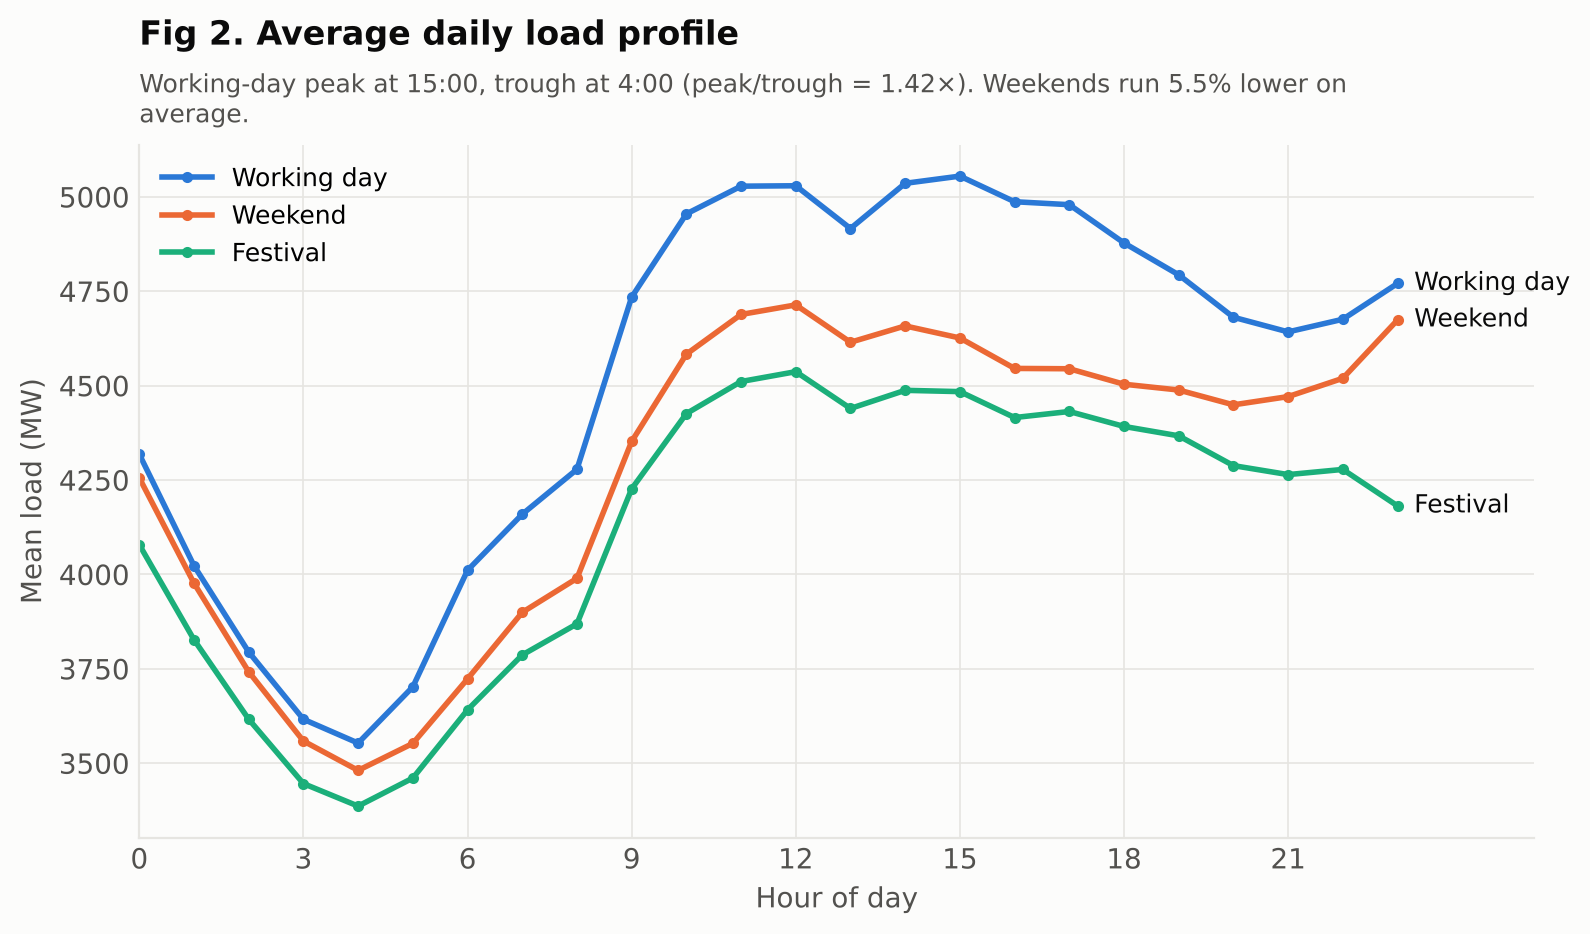

In [10]:
f02 = eda.f02_daily_profile(ctx); show("F02_daily_profile")

✅ **Finding.** Night trough around 04:00, daytime plateau, peak/trough ratio ≈ 1.4. Weekends run about 5% lower; festival days lower still.
🔧 **Decision.** Hour-of-day needs a rich encoding:
- **Trees:** the raw integer `hour` is fine, because trees split on thresholds.
- **Linear / MLP:** a straight line through hour = 0…23 is meaningless (it says 23:00 is "23 units" from 00:00, yet they are neighbours). Two fixes exist: a **cyclic encoding** $\sin(2\pi h/24), \cos(2\pi h/24)$, which puts the hours on a circle (2 columns, smooth), or **one-hot** hours (23 columns, any shape). The daily curve in Fig 2 has a dip at 13:00 and a double hump, so a smooth sin/cos pair is too rigid; we use **one-hot** for hour and weekday and **sin/cos** for month. (Using both for the same variable is redundant; see Section 5.)

### Fig 3 — Does the daily shape change with the season?
❓ This is the most important figure for model choice.

In [11]:
hm = obs.pivot_table(index="hour", columns="month", values="load_mw", aggfunc="mean")
peak_hour = hm.idxmax()                      # hour of maximum mean load, per month
pd.DataFrame({"peak hour": peak_hour, "peak MW": hm.max().round(0)}).T

month,1,2,3,4,5,6,7,8,9,10,11,12
peak hour,10.0,10.0,10.0,15.0,15.0,23.0,22.0,23.0,23.0,18.0,10.0,10.0
peak MW,5246.0,4340.0,3818.0,4522.0,5800.0,6698.0,6378.0,6146.0,5910.0,4570.0,3865.0,4407.0


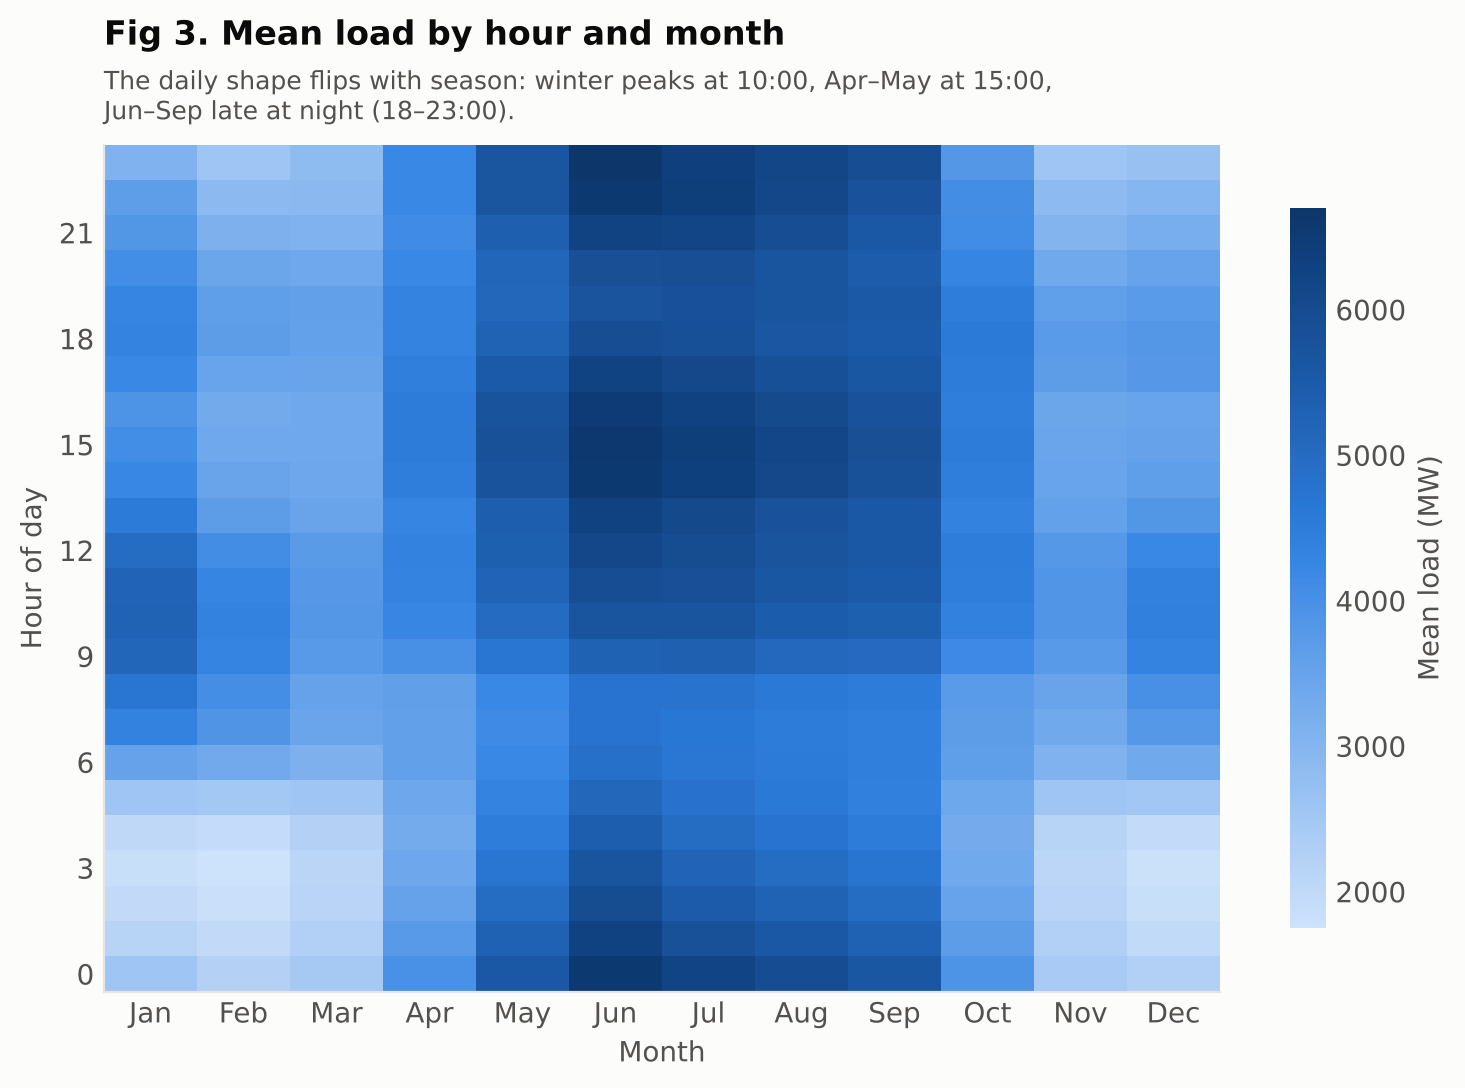

In [12]:
f03 = eda.f03_heatmap_hour_month(ctx); show("F03_heatmap_hour_month", 800)

✅ **Finding.** The daily shape **flips with the season**: winter peaks at 10:00, Apr–May at 15:00, Jun–Sep at 22–23:00 (late-night peak).
💡 **Course concept: interaction effects.** A linear model is *additive*: $\hat y = \dots + \beta_{hour}\cdot f(hour) + \beta_{month}\cdot g(month)$. It shifts the whole daily curve up or down by month, but it **cannot change the curve's shape**. Capturing a shape that changes needs an *interaction* term (hour × month), which trees and the MLP learn automatically.
🔧 **Expectation.** A clear accuracy gap between linear models (Phase 4) and non-linear models (Phases 5–6).

---
## 3. Memory in the series: autocorrelation

### Fig 8 — Which past hours carry information?
💡 **Autocorrelation** $\rho(k) = \mathrm{corr}(y_t, y_{t-k})$ measures how much the load $k$ hours ago resembles the load now. High $\rho(k)$ means $y_{t-k}$ is a useful feature, which is the justification for **lag features**.

In [13]:
from statsmodels.tsa.stattools import acf
y_train = ctx.hourly.loc[:ctx.TRAIN_END, "load_mw"]          # train only
rho = acf(y_train, nlags=340, fft=True)
pd.Series({f"lag {k}": rho[k] for k in [1, 2, 3, 24, 48, 120, 144, 168, 192, 336]}).round(3).to_frame("ACF").T

,lag 1,lag 2,lag 3,lag 24,lag 48,lag 120,lag 144,lag 168,lag 192,lag 336
ACF,0.979,0.931,0.869,0.965,0.937,0.898,0.898,0.899,0.881,0.836


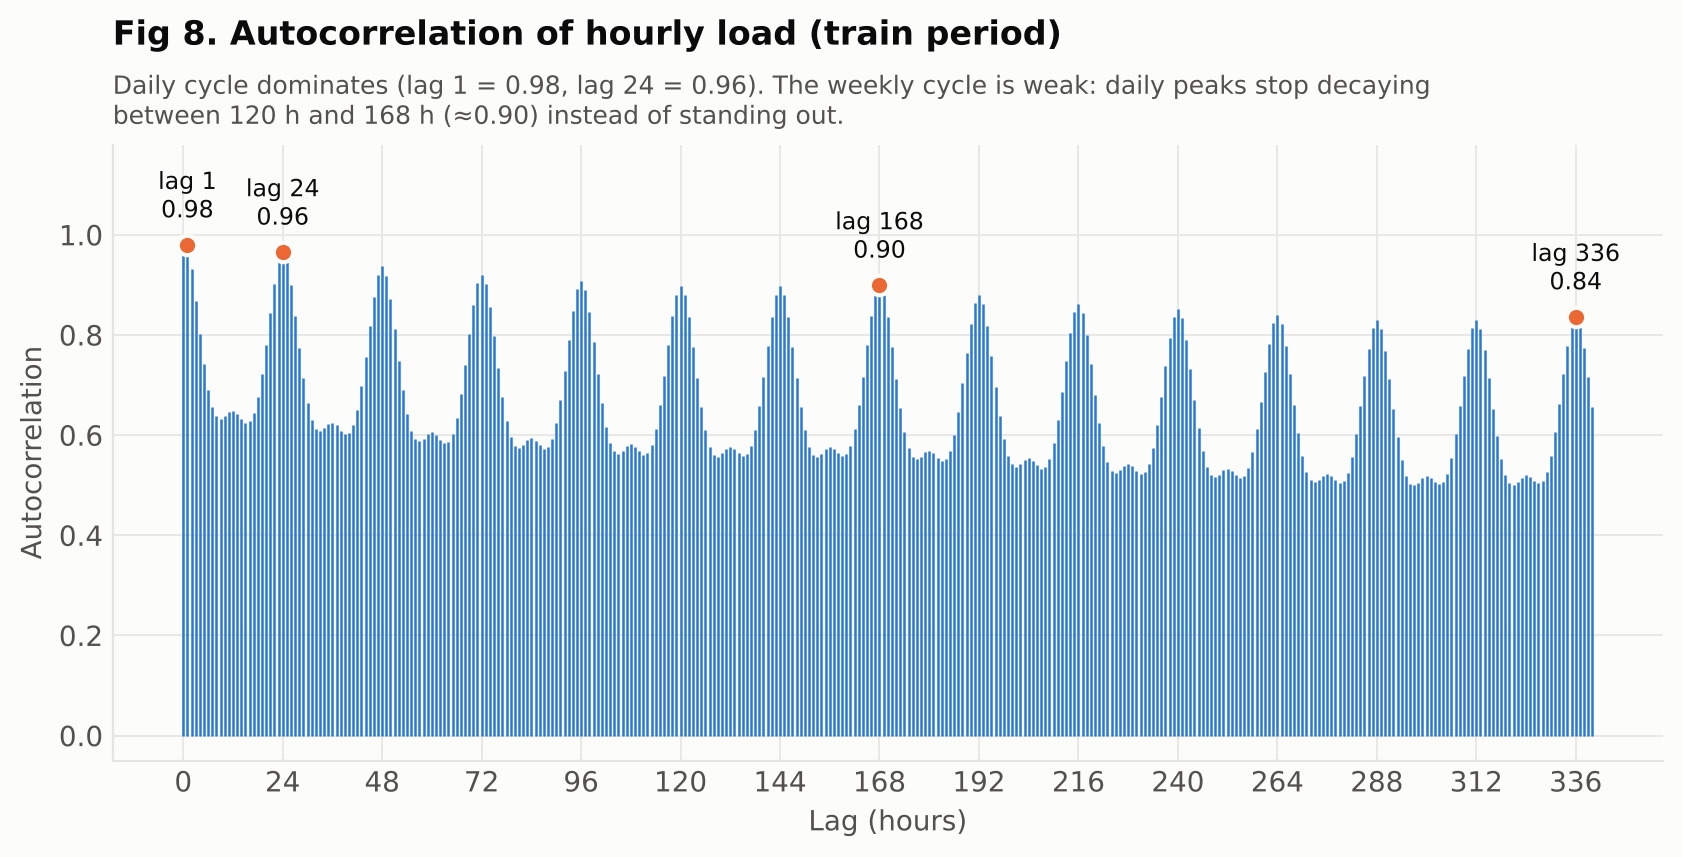

In [14]:
f08 = eda.f08_autocorrelation(ctx); show("F08_autocorrelation", 1000)

✅ **Finding.** Very strong memory: $\rho(1)=0.98$ and $\rho(24)=0.96$. The **daily** cycle dominates. The **weekly** cycle is weak: $\rho(168) \approx \rho(144) \approx 0.90$, so the correlation only stops decaying around one week instead of spiking there.
🔧 **Decisions.**
- Lags 1, 2, 3, 24 and 48 are strongly justified; lag 168 is kept but expected to matter little (Lasso will tell us).
- $\rho(1)=0.98$ means "next hour = this hour" is already a strong forecast. That's why Phase 3 builds **naive baselines**: every model must beat them to be worth anything.

---
## 4. Exogenous variables: weather and festivals

### Fig 5 — Does weather drive load beyond the calendar?
💡 **Course concept: confounding.** Temperature is high in the afternoon and in summer, and so is load. A raw correlation between them may only reflect that *both follow the calendar*.
To isolate weather's own effect we compute a **calendar-adjusted residual**: subtract the average load of the same (hour, weekday, month) cell. What remains is the part of demand the calendar cannot explain. If temperature really drives load, it should still correlate with this residual.

In [15]:
# the adjustment, step by step (same function the figure uses)
import inspect; print(inspect.getsource(eda.calendar_residual))

def calendar_residual(df, keys=("hour", "dow", "month")):
    """Load minus the mean load of the same calendar cell (e.g. same hour, weekday, month).
    What remains is the part of demand the calendar can NOT explain."""
    cell_mean = df.groupby(list(keys))["load_mw"].transform("mean")
    return df["load_mw"] - cell_mean



In [16]:
rows = []
t = train_obs.copy()
rows.append(("raw load (no adjustment)", t["temp"].corr(t["load_mw"]), t["humidity"].corr(t["load_mw"])))
for keys in [("hour", "dow", "month"), ("hour", "month")]:
    r = eda.calendar_residual(t, keys)
    rows.append((" × ".join(keys) + " adjusted", t["temp"].corr(r), t["humidity"].corr(r)))
# robustness: daily means, compared within the same month (are hotter days higher-load days?)
d = t.resample("D")[["load_mw", "temp"]].mean().dropna()
dd = d.groupby(d.index.to_period("M")).transform(lambda x: x - x.mean())
rows.append(("daily, within-month", dd["temp"].corr(dd["load_mw"]), np.nan))
pd.DataFrame(rows, columns=["comparison", "r(temperature)", "r(humidity)"]).set_index("comparison").map(lambda v: "—" if pd.isna(v) else f"{v:+.4f}")

,r(temperature),r(humidity)
comparison,,
raw load (no adjustment),+0.4616,+0.4765
hour × dow × month adjusted,+0.0000,-0.0022
hour × month adjusted,-0.0002,-0.0015
"daily, within-month",+0.0336,—


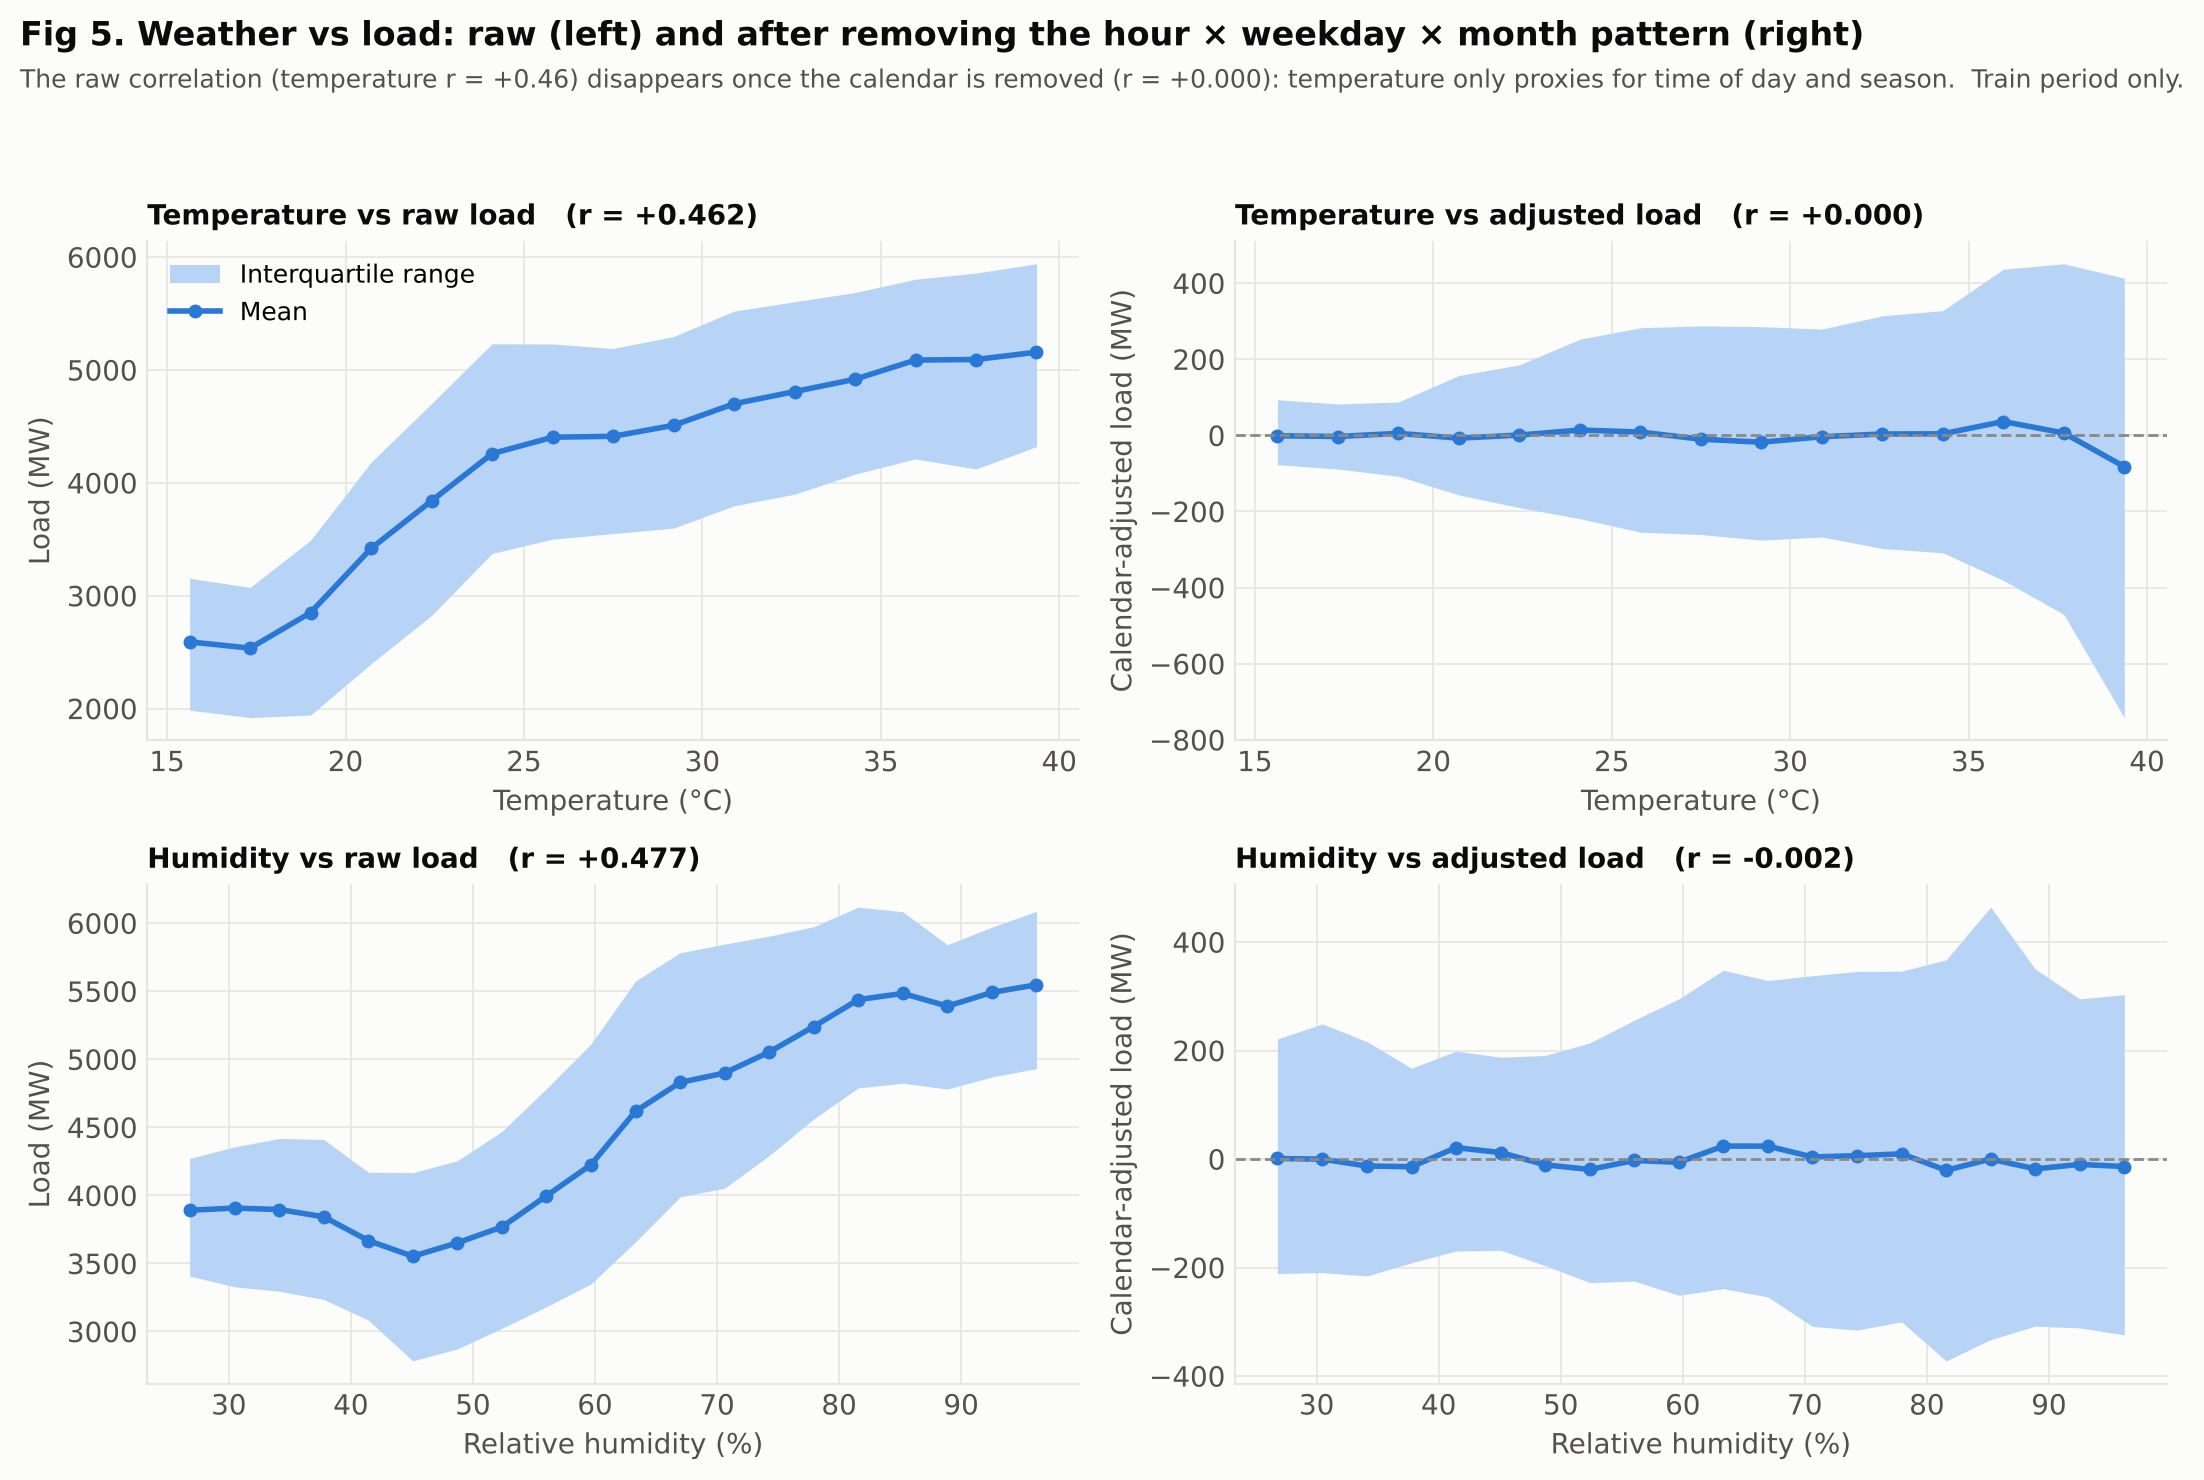

In [17]:
f05 = eda.f05_weather_confounding(ctx); show("F05_weather_confounding", 1000)

✅ **Finding.** The raw correlation (r ≈ +0.46) **vanishes** once the calendar is removed (r ≈ 0.000), and the result holds under three different adjustments. Within a month, hotter days are *not* higher-load days.
⚠️ **Data limitation (goes in the report).** In real Indian grid data, temperature normally drives cooling load. Its absence here suggests the weather columns may be synthetic or derived from the calendar.
🔧 **Decision.** Keep the weather features (the Phase 7 ablation will measure their contribution formally), but **expect ≈ 0 gain**. This also explains v1, where adding weather did not improve MAE.

### Fig 6 — Is the weather-condition label informative?
💡 Real weather is *persistent*: if it's raining now, it is likely raining in an hour. We test this with a **transition matrix** $P(\text{weather}_{h} \mid \text{weather}_{h-1})$. If the rows look like the overall frequencies, the label has no memory.

In [18]:
w = ctx.raw["weather"]
trans = pd.crosstab(w.shift(1), w, normalize="index")
p_same = (w == w.shift(1)).mean()
p_random = (w.value_counts(normalize=True) ** 2).sum()      # chance two independent draws match
print(f"P(same as previous hour) = {p_same:.3f}   vs   {p_random:.3f} if independent")
trans.round(2)

P(same as previous hour) = 0.370   vs   0.336 if independent


weather,Clear,Cloudy,Rain,Storm
weather,,,,
Clear,0.51,0.29,0.14,0.06
Cloudy,0.45,0.30,0.17,0.07
Rain,0.38,0.30,0.24,0.08
Storm,0.41,0.29,0.21,0.09


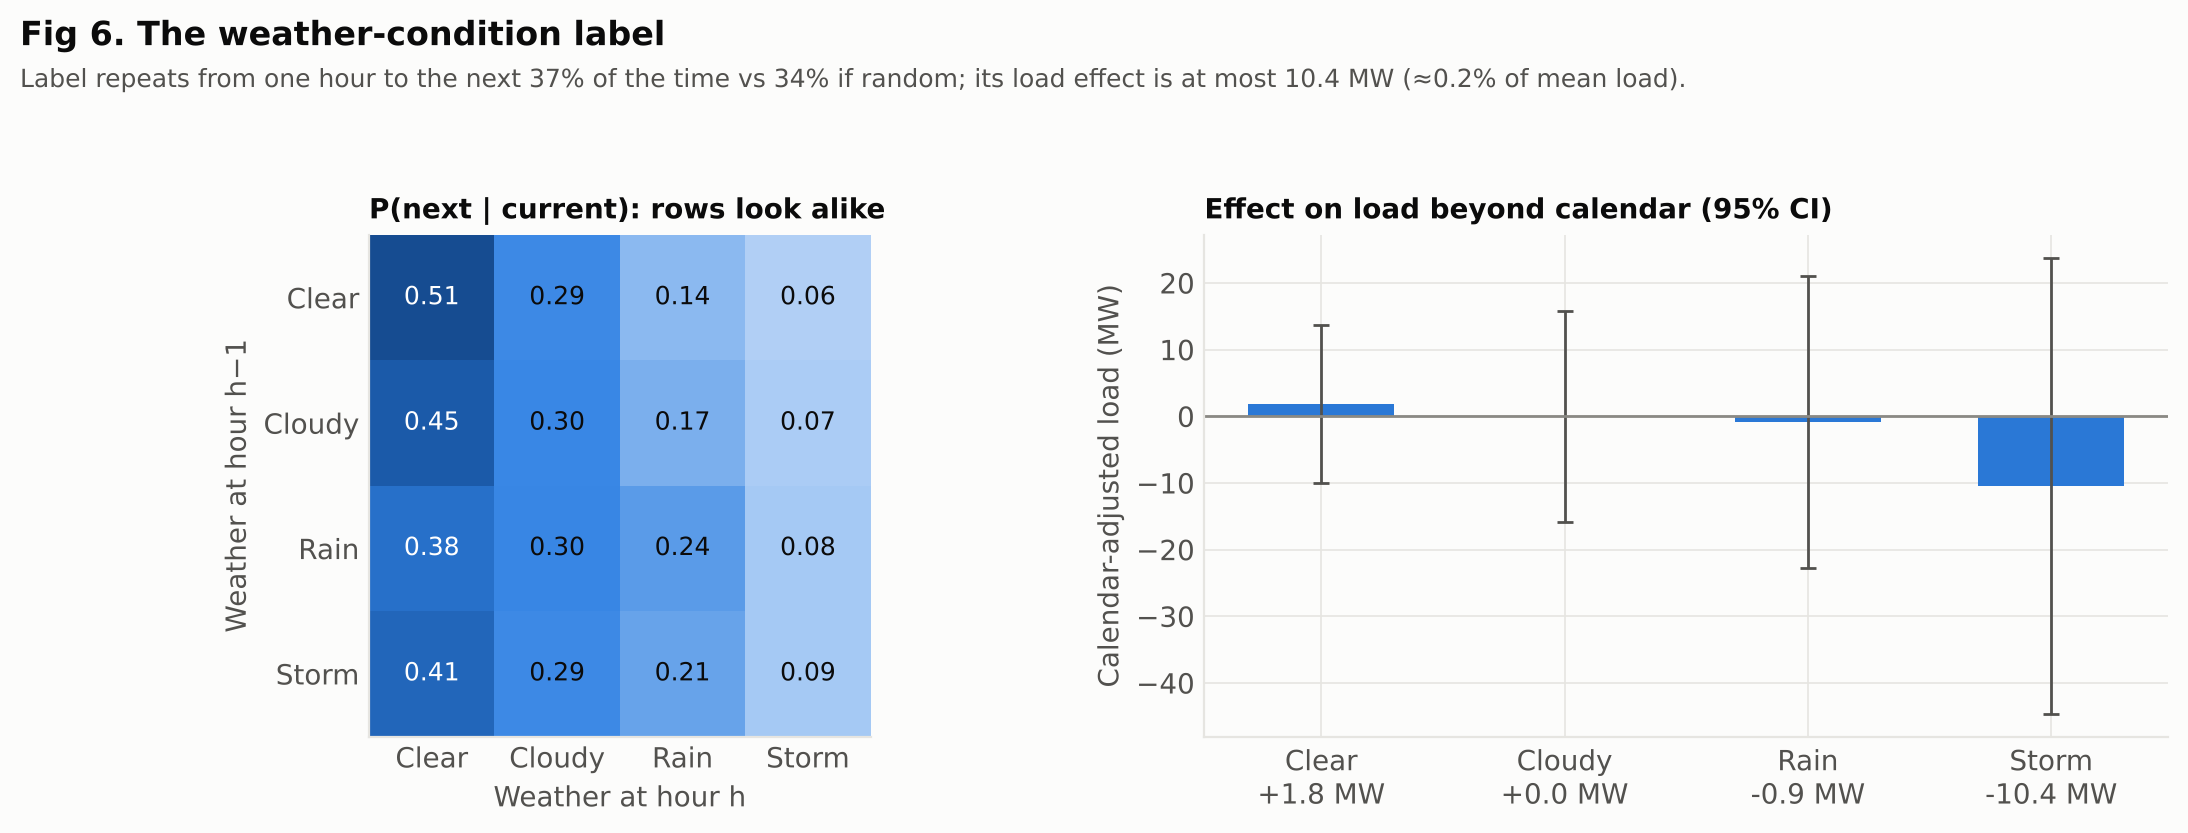

In [19]:
f06 = eda.f06_weather_label(ctx); show("F06_weather_label", 1000)

✅ **Finding.** The label repeats 37% of the time against 34% by chance, so it is nearly memoryless hour to hour. Its effect on load is a few MW (≈ 0.2%), with confidence intervals spanning zero. The only real signal is seasonal (more rain in Jun–Sep), which the month features already carry.
🔧 **Decision.** Keep the lagged one-hot encoding; we expect **Lasso (L1) to set these coefficients to zero**. That will be a nice demonstration of L1 feature selection in Phase 4.

### Fig 7 — Do festivals and weekends change load?

In [20]:
t = train_obs.copy()
t["day_type"] = np.select([t["holiday_type"] == "Festival", t["dow"] >= 5], ["Festival", "Weekend"], "Working day")
t["resid_hm"] = eda.calendar_residual(t, ("hour", "month"))   # keep weekday OUT of the adjustment here
g = t.groupby("day_type")["resid_hm"].agg(["mean", "sem", "size"])
g["95% CI ±"] = 1.96 * g["sem"]
g[["mean", "95% CI ±", "size"]].round(1)

,mean,95% CI ±,size
day_type,,,
Festival,-101.2,37.0,1162
Weekend,-172.1,15.6,4576
Working day,81.6,10.9,11096


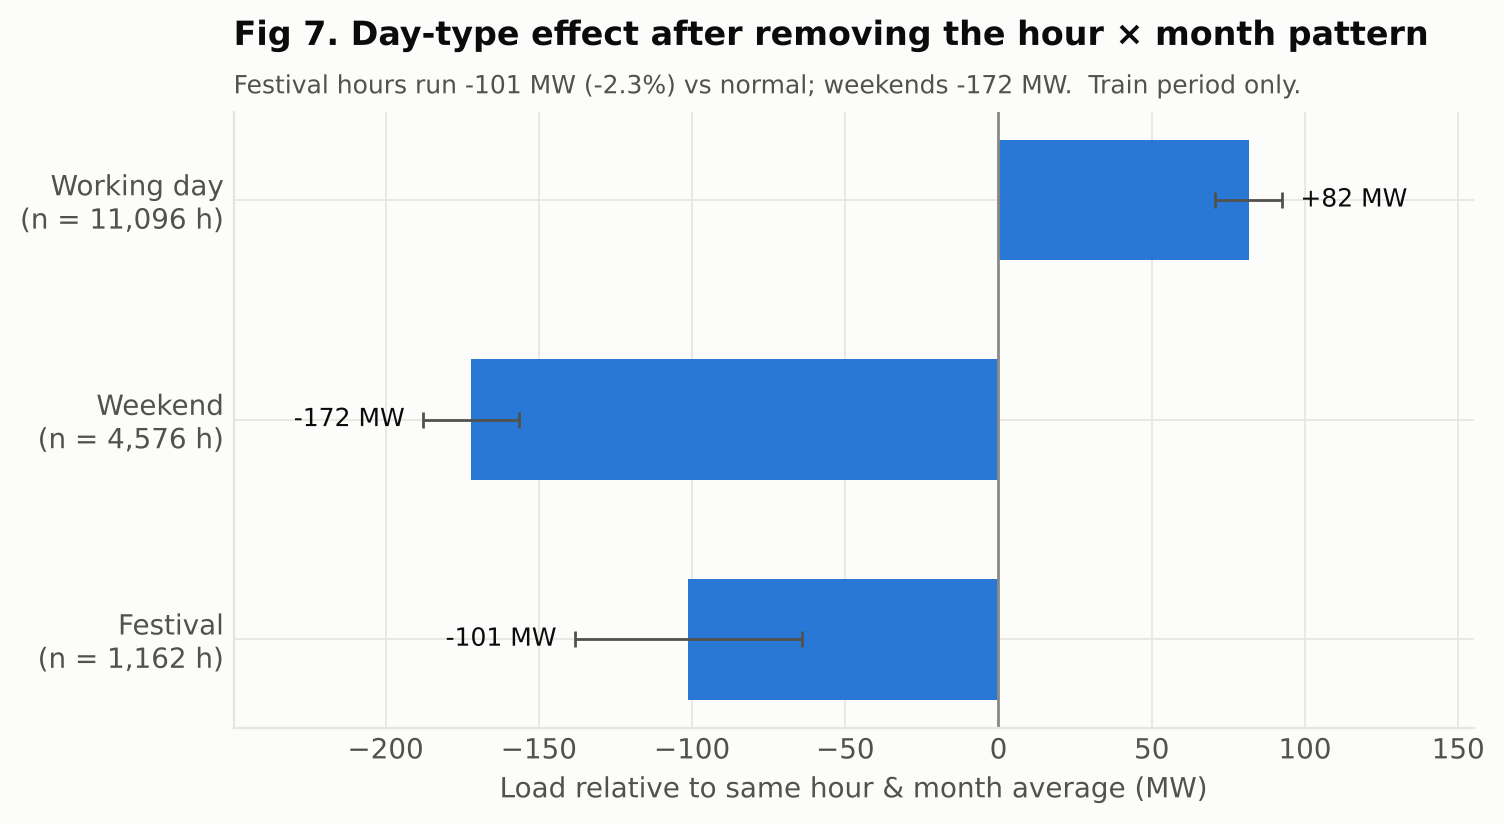

In [21]:
f07 = eda.f07_day_type_effect(ctx); show("F07_day_type_effect")

✅ **Finding.** Festival hours run about 100 MW (≈ 2.3%) below a normal hour of the same hour and month; weekends about 170 MW below. The confidence intervals exclude zero, so both effects are real.
🔧 **Decision.** Keep `is_festival` and `is_weekend`. Festivals are only about 7% of hours, so the *overall* gain will be small, but it should show up clearly when we evaluate festival hours separately.

---
## 5. Feature relationships and multicollinearity

### Fig 9 — Which features relate linearly to the target?

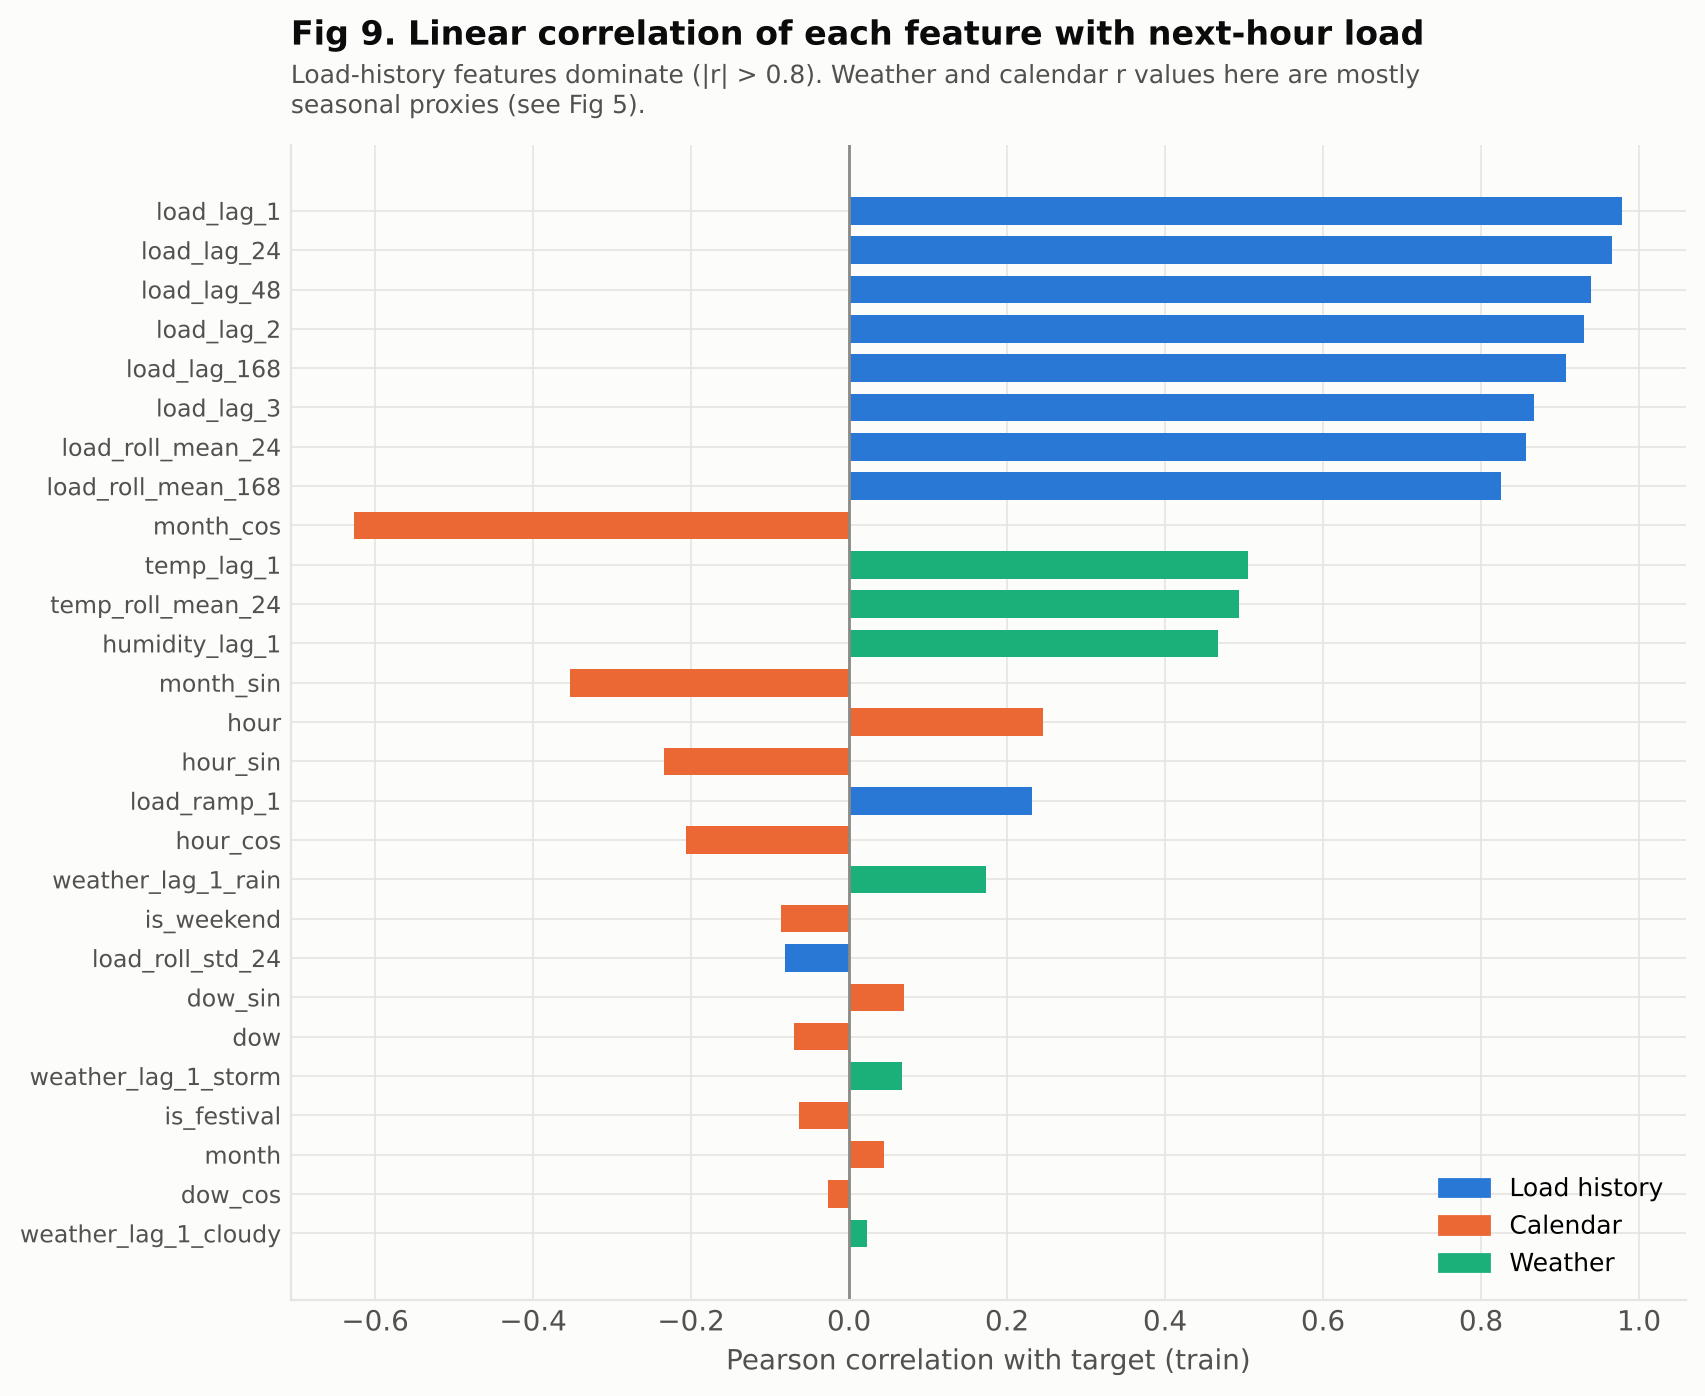

In [22]:
f09 = eda.f09_feature_correlation(ctx); show("F09_feature_correlation", 800)

💡 **Course concept: multicollinearity → why we need regularisation.** The load-lag features are highly correlated *with each other*. Ordinary least squares solves $\hat\beta = (X^\top X)^{-1} X^\top y$. When columns of $X$ are nearly collinear, $X^\top X$ is **ill-conditioned** (nearly singular): tiny changes in the data cause huge swings in $\hat\beta$. Two standard diagnostics:
- **Condition number** of the standardised $X$: values above ~30 indicate harmful collinearity.
- **Variance Inflation Factor** $\mathrm{VIF}_j = 1/(1-R_j^2)$: how much feature $j$ is explained by the others. VIF > 10 is a red flag.

In [23]:
import warnings
from statsmodels.stats.outliers_influence import variance_inflation_factor

def collinearity(cols):
    X = sp.train[cols]
    X = (X - X.mean()) / X.std()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        vif = pd.Series([variance_inflation_factor(X.values, i) for i in range(len(cols))], index=cols)
    return np.linalg.cond(X.values), vif

cond_all, vif_all = collinearity(features.LOAD)          # first attempt: all load features
print(f"Condition number, all load features: {cond_all:.2e}")
vif_all.sort_values(ascending=False).map(lambda v: f"{v:.3g}").to_frame("VIF").T

Condition number, all load features: 1.02e+16


,load_lag_1,load_lag_2,load_ramp_1,load_lag_3,load_roll_mean_24,load_roll_mean_168,load_lag_24,load_lag_48,load_lag_168,load_roll_std_24
VIF,1e+15,1e+15,1e+15,57.8,34.5,33,31.9,21.7,10.5,1.07


⚠️ **The evaluator caught a feature-design defect here.** A condition number of about $10^{16}$ and VIFs of about $10^{15}$ are not "high collinearity": they mean **exact** linear dependence. The culprit is
$$\texttt{load\_ramp\_1} = \texttt{load\_lag\_1} - \texttt{load\_lag\_2},$$
so $X^\top X$ is singular and OLS has **no unique solution**.
A full-rank test written for this fix then found **five more** exact dependencies in the calendar encoding: `is_weekend = dow_5 + dow_6`, and $\sin/\cos$ of hour and weekday are fixed linear combinations of their one-hot columns (given an intercept). Lesson: *one-hot and cyclic encodings of the same variable are redundant for a linear model*, so pick one.
🔧 **Fix (in `src/features.py`).** Keep `load_ramp_1` for **trees**, which split on one feature at a time and can't easily form differences themselves. Drop it from the **linear / MLP** feature set, where it adds no information because it lies in the span of the other columns. For the calendar, the linear set keeps **one-hot hour and weekday** (more flexible than sin/cos) and **sin/cos month**. A test now checks that the linear design matrix has full rank.

In [24]:
cond_lin, vif_lin = collinearity(features.LOAD_LINEAR)   # after the fix
print(f"Condition number, linear-model load features: {cond_lin:,.1f}")
vif_lin.sort_values(ascending=False).round(1).to_frame("VIF").T

Condition number, linear-model load features: 45.2


,load_lag_2,load_lag_1,load_lag_3,load_roll_mean_24,load_roll_mean_168,load_lag_24,load_lag_48,load_lag_168,load_roll_std_24
VIF,174.2,89.8,57.8,34.5,33.0,31.9,21.7,10.5,1.1


✅ **Finding.** Even after removing the exact dependency, the load features remain **strongly collinear**: several VIFs are well above 10 and the condition number is high. That is the real, unavoidable multicollinearity of a time series with strong memory.
🔧 **Decision → Phase 4.** This is exactly the problem **Ridge (L2)** solves. Adding $\alpha\|\beta\|_2^2$ to the loss gives $\hat\beta = (X^\top X + \alpha I)^{-1}X^\top y$; the $\alpha I$ term lifts the small eigenvalues, so the inverse is stable. **Lasso (L1)** goes further and drops redundant features entirely (sparse $\hat\beta$). Both problems are **convex**, so they have a unique global optimum that is cheap to find, and $\alpha$ is tuned by time-series cross-validation.

---
## 6. Summary: from EDA to modelling decisions
Each row below was produced by the code above and saved to `results/tables/phase2_eda_findings.csv`, the single source of truth for the report.

In [25]:
findings = pd.DataFrame([f10, f11, f01, f04, f02, f03, f08, f05, f06, f07, f09]).sort_values("figure")
findings.to_csv(config.TABLE_DIR / "phase2_eda_findings.csv", index=False)
with pd.option_context("display.max_colwidth", None):
    display(findings[["figure", "question", "modelling_decision"]].style.hide(axis="index")
            .set_properties(**{"text-align": "left", "white-space": "pre-wrap"}))

figure,question,modelling_decision
F01,How does load evolve and where do the splits fall?,"Correction to the Phase 1 note: the Train/Val gap is seasonal, not a growth trend. Month/seasonal features are needed; trees should cope because Train contains two summers."
F02,What does a typical day look like?,"Hour-of-day must be encoded richly: one-hot + sin/cos for linear/MLP, raw hour for trees. Keep is_weekend."
F03,Does the daily shape change with season?,"Hour×month interaction: an additive linear model can't capture it, but trees and the MLP can. Expect a clear gap between linear and non-linear models."
F04,Is there a growth trend the models must extrapolate?,"No de-trending step: Train already contains the higher 2024 level, and the lags and rolling means carry the recent level into each forecast. Test (H2 2025) sits on the plateau."
F05,Does weather drive load beyond the calendar?,"Keep the weather features (the ablation will test them), but expect ≈0 gain. Consistent with v1, where adding weather did not improve MAE. Report it as a data limitation."
F06,Is the weather label informative?,Only seasonal information (more rain in Jun–Sep). Lagged one-hot kept for completeness; Lasso should zero it out.
F07,Do festivals and weekends change load?,"Keep is_festival and is_weekend: small but real effects. Festivals are rare (≈7% of hours), so expect a small overall gain that is larger on festival hours."
F08,Which past hours carry information?,"Justifies lags 1–3, 24 and 48. Lag 168 is kept but expected to add little; Lasso will tell. Lag 1 alone should give a strong naive baseline (Phase 3), and naive-24 should beat naive-168."
F09,Which features relate linearly to the target?,"Strong collinearity among load lags (lag1, lag2, lag3, roll_mean_24): plain OLS coefficients will be unstable. This motivates Ridge (L2) and Lasso (L1) in Phase 4."
F10,How complete is the data?,"Phase 1 policy holds: forward-fill ≤3 h, seasonal fill for long gaps (history only), imputed hours never scored."


### What we expect in the next phases (to be checked against actual results)

| Expectation | Based on | Checked in |
|---|---|---|
| Naive "previous hour" is a strong baseline; naive-24 beats naive-168 | Fig 8 (ACF) | Phase 3 |
| Ridge/Lasso beat OLS only slightly in accuracy but give far more stable coefficients; Lasso zeroes weather | Figs 6, 9, VIF | Phase 4 |
| Non-linear models (XGBoost, MLP) clearly beat linear models | Fig 3 (hour × month interaction) | Phases 5–6 |
| Weather adds ≈ 0; festival flag helps mainly on festival hours | Figs 5–7 | Phase 7 ablation |
| Largest errors in summer late-night peaks and on festival days | Figs 3, 7, 11 | Phase 7 error analysis |

*Writing expectations down **before** modelling, then checking them, is what turns an EDA into evidence.*